In [51]:
# install libraries
# %pip install statsmodels

In [52]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose # for seasonal decomposition

In [53]:
# set style to better visualization
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)

In [54]:
# create a sample time series data
np.random.seed(42)
# date range from 2020 to 2023 with monthly frequency
date_range = pd.date_range(start='2020-01-01', end='2023-12-31', freq='ME')

# create synthetic sales data
base_trend = np.linspace(100, 200, len(date_range)) # linear trend
seasonal_pattern = 20 * np.sin(2 * np.pi * date_range.month / 12) # seasonal pattern
noise = np.random.normal(0, 15, len(date_range)) # random noise

sales_data = base_trend + seasonal_pattern + noise

In [55]:
df = pd.DataFrame({'Date': date_range, 'Sales': sales_data})
df.set_index('Date', inplace=True)
df.head()

,Sales
Date,
2020-01-31,117.450712
2020-02-29,117.374203
2020-03-31,133.970647
2020-04-30,146.548935
2020-05-31,114.998338


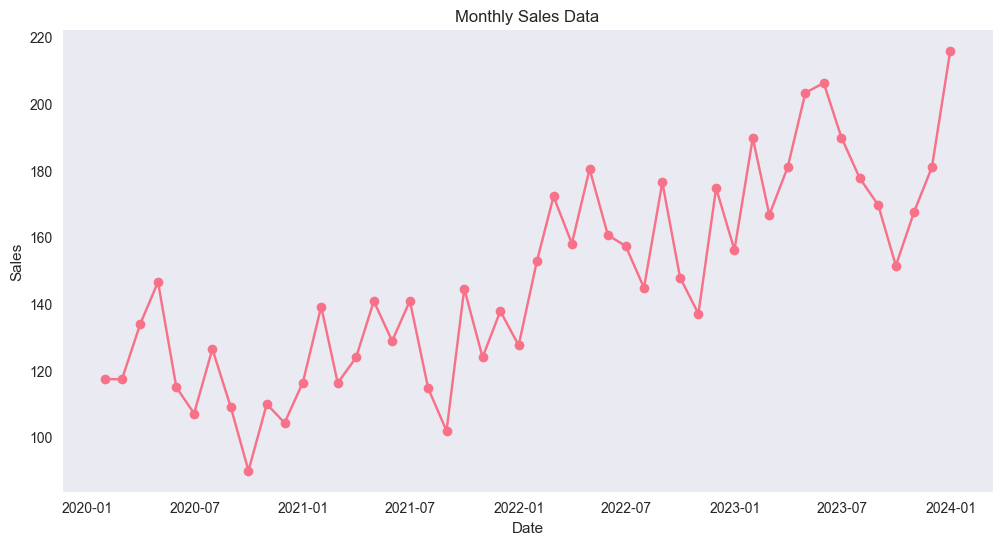

In [56]:
# basic visualization of the time series data
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Sales'], marker='o')
plt.title('Monthly Sales Data')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid()
plt.show()

In [57]:
df.shape # check data shape
print(df['Sales'].describe()) # check data statistics


count     48.000000
mean     146.920540
std       30.409588
min       89.979161
25%      122.297778
50%      144.671056
75%      170.283183
max      215.856833
Name: Sales, dtype: float64


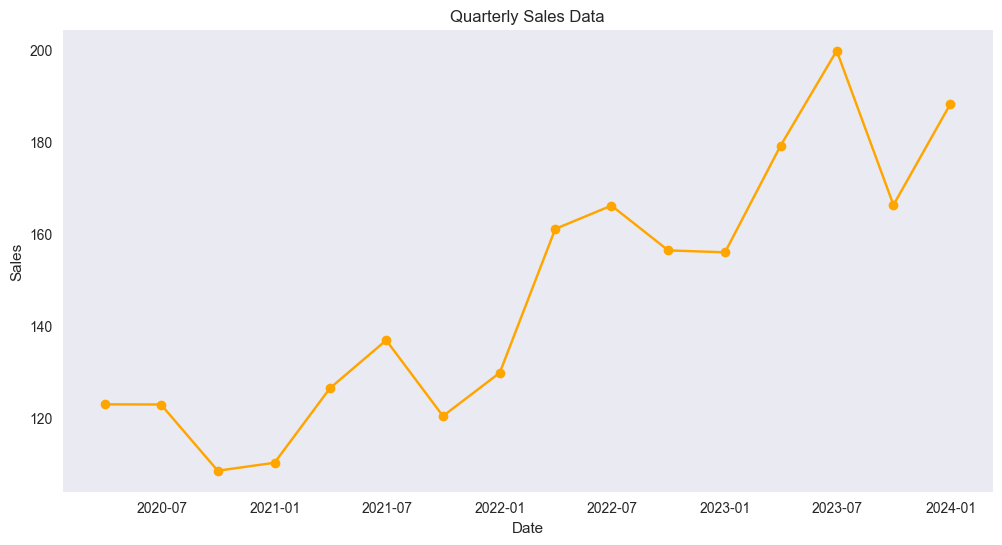

In [58]:
# check resampling of the data to yearly frequency

# monthly to Quarterly
df_quarterly = df.resample('QE').mean()

plt.figure(figsize=(12, 6))
plt.plot(df_quarterly.index, df_quarterly['Sales'], marker='o', color='orange')
plt.title('Quarterly Sales Data')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid()
plt.show()

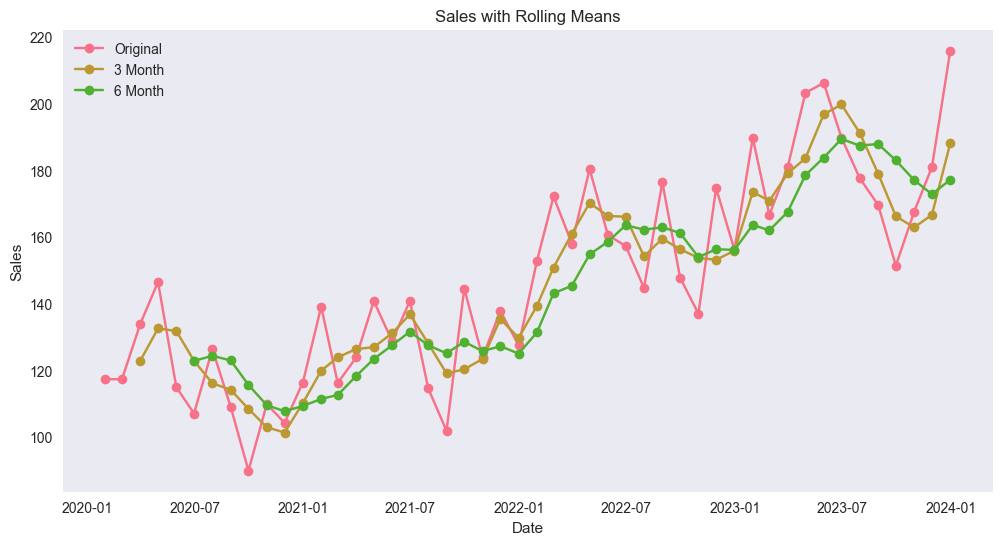

In [59]:
# rolling mean and rolling
df['MA_3'] = df['Sales'].rolling(window=3).mean() # 3 month rolling mean
df['MA_6'] = df['Sales'].rolling(window=6).mean() # 6 month rolling mean

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Sales'], marker='o', label='Original')
plt.plot(df.index, df['MA_3'], marker='o', label='3 Month') 
plt.plot(df.index, df['MA_6'], marker='o', label='6 Month')
plt.title('Sales with Rolling Means')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()


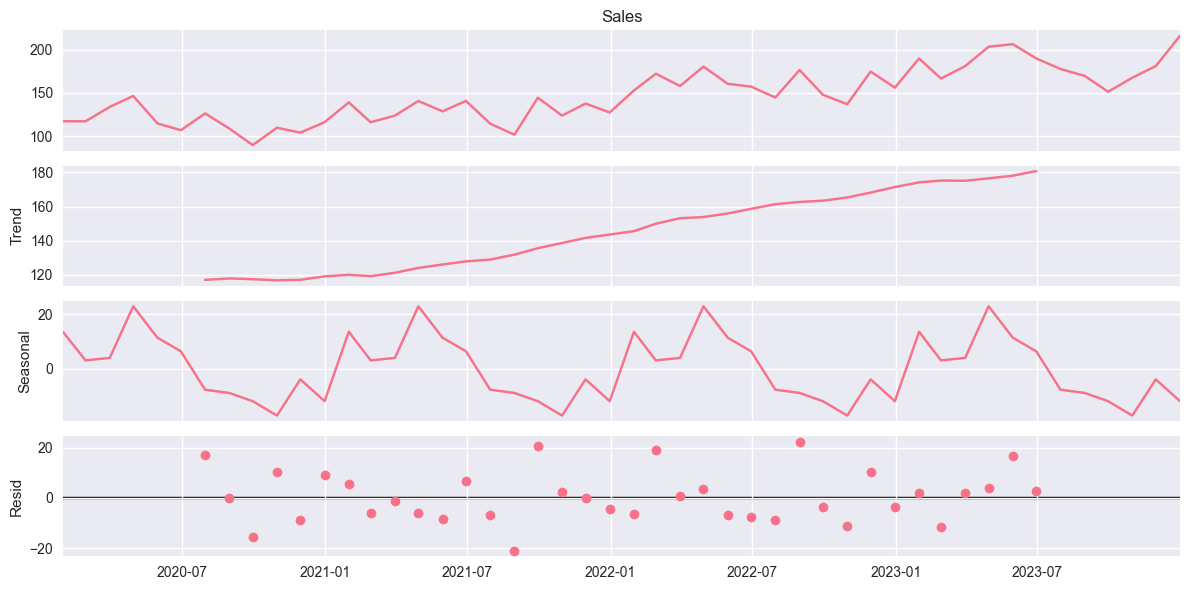

In [60]:
# decomposition of the time series data
decomposition = seasonal_decompose(df['Sales'], model='additive', period=12)
decomposition.plot()
plt.show()